In [ ]:
import pandas as pd
import numpy as np

# Adjust the filename to match whatever you downloaded from Kaggle
file_path = '../data/raw/data_science_job_posts_2025.csv'
df = pd.read_csv(file_path)

# 1. Look at the first 5 rows
display(df.head())

# 2. Get the basic info
df.info()

# 3. See exactly how many missing values you have in each column
print(df.isnull().sum())

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB
job_title            3
seniority_level     60
status             256
company              0
location             2
post_date            0
headquarter          0
industry         

In [3]:
import pandas as pd
import numpy as np
import ast

# 1. Remove the Euro symbol and commas
df['salary_clean'] = df['salary'].str.replace('€', '', regex=False).str.replace(',', '', regex=False)

# 2. Function to split the range into Min and Max
def extract_salary(sal_str):
    if pd.isna(sal_str):
        return np.nan, np.nan

    parts = str(sal_str).split('-')
    if len(parts) == 2:
        return float(parts[0].strip()), float(parts[1].strip())
    else:
        # If it's a single number, we set both min and max to that number
        val = float(parts[0].strip())
        return val, val

# 3. Apply the function and create new columns
df[['min_salary', 'max_salary']] = df['salary_clean'].apply(lambda x: pd.Series(extract_salary(x)))

# 4. Calculate the average salary
df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

# Drop the messy intermediate column
df.drop(columns=['salary_clean'], inplace=True)

In [4]:
# Function to safely evaluate the string as a Python list
def parse_skills(skill_str):
    try:
        # ast.literal_eval safely turns "['a', 'b']" into ['a', 'b']
        return ast.literal_eval(skill_str)
    except (ValueError, SyntaxError):
        return []

df['skills_list'] = df['skills'].apply(parse_skills)

In [ ]:
# Fill missing categorical data with 'Not Specified'
df['seniority_level'] = df['seniority_level'].fillna('Not Specified')
df['status'] = df['status'].fillna('Not Specified')

# Result
display(df[['salary', 'min_salary', 'max_salary', 'avg_salary', 'skills_list']].head())

,salary,min_salary,max_salary,avg_salary,skills_list
0,"€100,472 - €200,938",100472.0,200938.0,150705.0,"[spark, r, python, scala, machine learning, te..."
1,"€118,733",118733.0,118733.0,118733.0,"[spark, r, python, sql, machine learning]"
2,"€94,987 - €159,559",94987.0,159559.0,127273.0,"[aws, git, python, docker, sql, machine learni..."
3,"€112,797 - €194,402",112797.0,194402.0,153599.5,"[sql, r, python]"
4,"€114,172 - €228,337",114172.0,228337.0,171254.5,[]


In [6]:
# Define the path where you want to save the clean data
output_dir = '../data/processed'
output_file = f'{output_dir}/cleaned_job_data.csv'

# Save the dataframe to a CSV file
# (index=False prevents pandas from writing row numbers as a new column)
df.to_csv(output_file, index=False)

print(f"✅ Success! Clean data saved to: {output_file}")

✅ Success! Clean data saved to: ../data/processed/cleaned_job_data.csv


--- Top 10 Skills ---
skills_list
python              640
machine learning    580
sql                 442
r                   343
aws                 218
deep learning       178
tensorflow          165
spark               161
azure               155
pytorch             148
Name: count, dtype: int64




C:\Users\Hp\AppData\Local\Temp\ipykernel_10784\407754176.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')


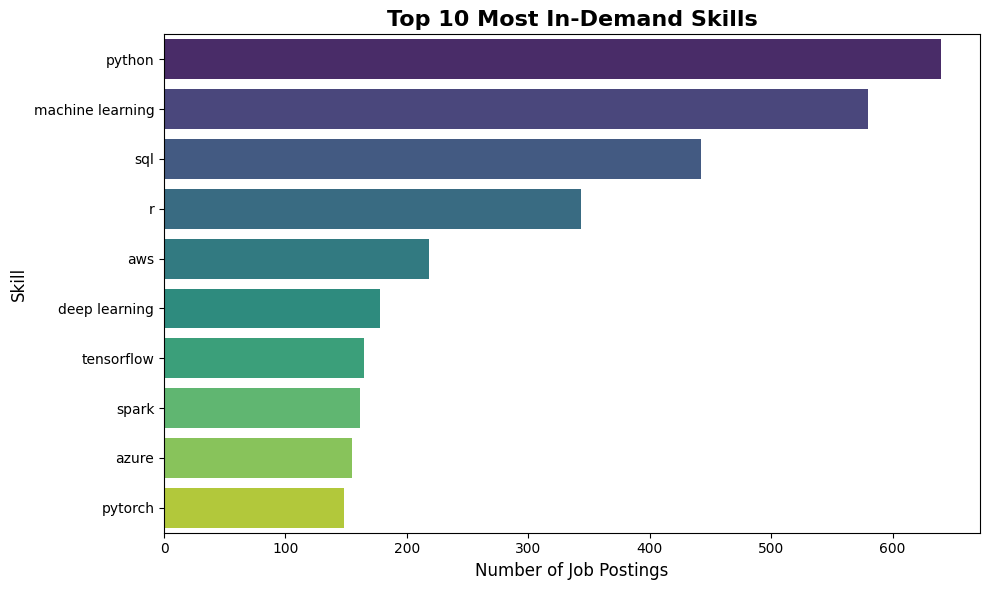

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. "Explode" the skills list so each skill gets its own row
exploded_skills = df.explode('skills_list')

# 2. Count the occurrences of each skill and grab the Top 10
top_skills = exploded_skills['skills_list'].dropna().value_counts().head(10)

# 3. Print the raw numbers
print("--- Top 10 Skills ---")
print(top_skills)
print("\n")

# 4. Create a Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')

# Add labels and formatting
plt.title('Top 10 Most In-Demand Skills', fontsize=16, fontweight='bold')
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Skill', fontsize=12)
plt.tight_layout()

plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_10784\767979185.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


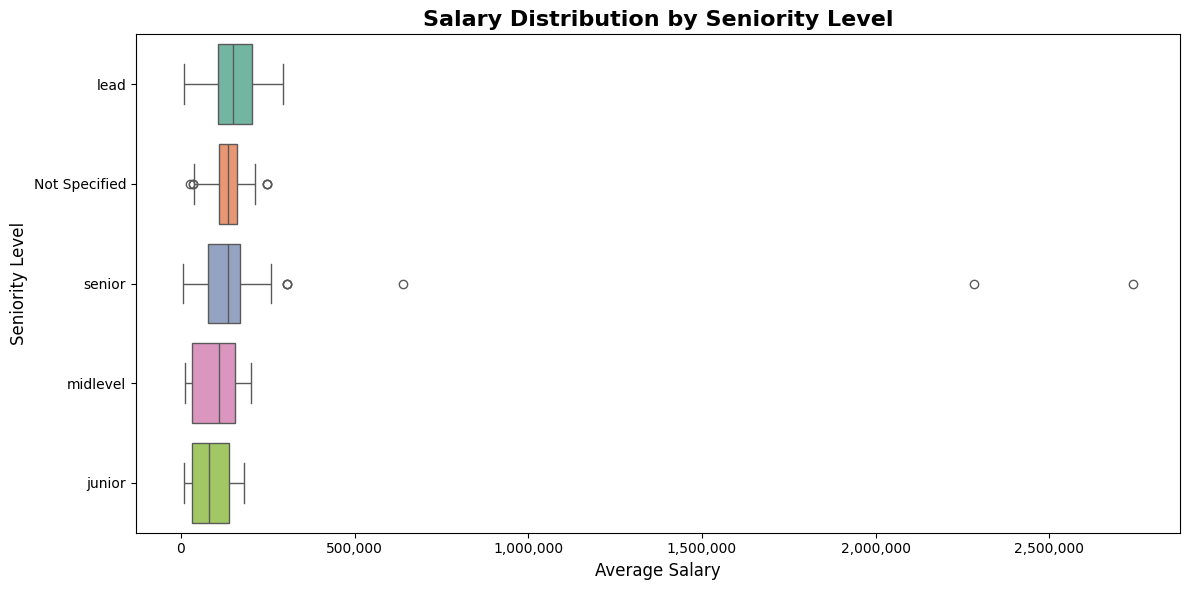

--- Median Salary by Seniority ---
seniority_level
lead             148855.25
Not Specified    137003.25
senior           134766.00
midlevel         109147.50
junior            80123.00
Name: avg_salary, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Drop rows where salary is missing
salary_df = df.dropna(subset=['avg_salary'])

# 2. Figure out the order (from highest median salary to lowest)
seniority_order = salary_df.groupby('seniority_level')['avg_salary'].median().sort_values(ascending=False).index

# 3. Create the Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=salary_df,
    x='avg_salary',
    y='seniority_level',
    order=seniority_order,
    palette='Set2'
)

# 4. Formatting to make it look highly professional
plt.title('Salary Distribution by Seniority Level', fontsize=16, fontweight='bold')
plt.xlabel('Average Salary', fontsize=12)
plt.ylabel('Seniority Level', fontsize=12)

# Format the x-axis to show numbers with commas
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

# 5. Print the exact median numbers for a quick sanity check
print("--- Median Salary by Seniority ---")
print(salary_df.groupby('seniority_level')['avg_salary'].median().sort_values(ascending=False))